# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
- **URL Sumber Dataset:** https://github.com/ersaaz988/Eksperimen_SML_Ergi
- **Deskripsi dan Konteks Data:** Dataset ini merupakan kumpulan ulasan (reviews) pengguna terhadap aplikasi finansial (fintech) di Indonesia. Data terdiri dari teks ulasan mentah yang kemudian diberi label sentimen (Positif, Negatif, Netral) untuk digunakan dalam melatih model klasifikasi berbasis Machine Learning dan Deep Learning.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, SpatialDropout1D, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style='whitegrid')
tqdm.pandas()

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [7]:
print("[INFO] Memuat Data...")
df = pd.read_csv('dataset_fintech_agregasi.csv')
print("[INFO] Dataset bersih berhasil disimpan untuk alur eksperimen.")

[INFO] Memuat Data...
[INFO] Dataset bersih berhasil disimpan untuk alur eksperimen.


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

[INFO] Memulai Exploratory Data Analysis (EDA)...


/tmp/ipykernel_3874/3658692644.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentimen', palette='Set2', order=['Positif', 'Netral', 'Negatif'])


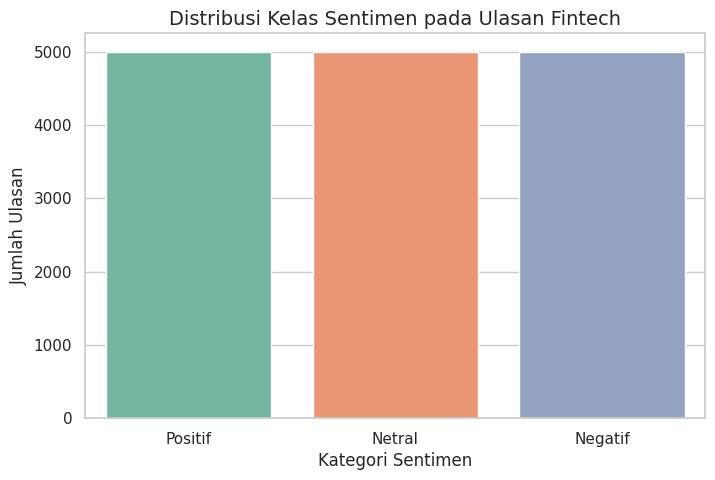

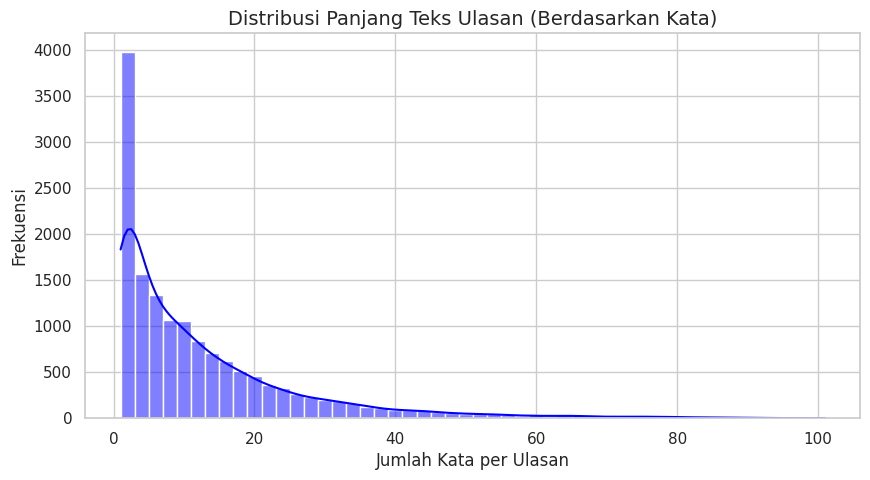


Statistik Deskriptif Panjang Ulasan (Kata):
count    15000.000000
mean        12.322800
std         14.026774
min          1.000000
25%          2.000000
50%          8.000000
75%         17.000000
max        101.000000
Name: jumlah_kata_mentah, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi
sns.set(style='whitegrid')

print("[INFO] Memulai Exploratory Data Analysis (EDA)...")

# 1. Visualisasi Distribusi Sentimen
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentimen', palette='Set2', order=['Positif', 'Netral', 'Negatif'])
plt.title('Distribusi Kelas Sentimen pada Ulasan Fintech', fontsize=14)
plt.xlabel('Kategori Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.show()

# 2. Analisis Panjang Teks (Jumlah Kata per Ulasan Mentah)
# Menghitung jumlah kata sebelum dibersihkan
df['jumlah_kata_mentah'] = df['teks'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['jumlah_kata_mentah'], bins=50, kde=True, color='blue')
plt.title('Distribusi Panjang Teks Ulasan (Berdasarkan Kata)', fontsize=14)
plt.xlabel('Jumlah Kata per Ulasan', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

# 3. Statistik Deskriptif Panjang Teks
print("\nStatistik Deskriptif Panjang Ulasan (Kata):")
print(df['jumlah_kata_mentah'].describe())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Karena dataset yang digunakan adalah data teks tidak terstruktur (ulasan pengguna), tahapan preprocessing disesuaikan untuk membersihkan *noise* pada bahasa natural. Berikut adalah tahapan yang dilakukan:
1. **Normalisasi Fitur (Text Cleaning & Slang Normalization):** Mengubah teks menjadi huruf kecil (*case folding*), menghapus karakter non-alfabet (tanda baca/angka), dan menstandarisasi kata tidak baku (*slang*) menggunakan kamus buatan sendiri.
2. **Stopword Removal & Stemming:** Menghapus kata hubung yang tidak memiliki makna sentimen menggunakan Sastrawi, lalu mengembalikan kata ke bentuk dasarnya (*stemming*).
3. **Menangani Data Kosong (Missing Values):** Setelah proses pembersihan teks, beberapa baris mungkin menjadi kosong (karena hanya berisi tanda baca atau emoji sebelumnya). Baris kosong ini di-drop menggunakan `dropna()`.
4. **Deteksi dan Penanganan Outlier (Berdasarkan Panjang Kata):** Menghitung jumlah kata pada teks yang sudah dibersihkan. Ulasan yang terlalu pendek (0 kata) atau terlalu panjang (lebih dari 60 kata) dianggap sebagai *outlier* dan dihapus dari dataset untuk menjaga kualitas model.

In [9]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("[INFO] Memulai Preprocessing Teks...")

# 1. Inisialisasi Kamus Slang
slang_dict = {
    "yg": "yang", "gk": "tidak", "ga": "tidak", "gak": "tidak", "ngga": "tidak", "engga": "tidak",
    "sdh": "sudah", "udah": "sudah", "blm": "belum", "dr": "dari", "klo": "kalau",
    "kalo": "kalau", "bs": "bisa", "sy": "saya", "aku": "saya", "gue": "saya", "gw": "saya",
    "bgt": "banget", "anj": "buruk", "jelek": "buruk", "parah": "buruk", "kecewa": "buruk",
    "lola": "lambat", "lemot": "lambat", "lelet": "lambat", "cepet": "cepat",
    "top": "bagus", "good": "bagus", "mantap": "bagus", "keren": "bagus", "ok": "bagus",
    "tf": "transfer", "wd": "tarik", "topup": "isi ulang", "saldo": "uang", "cuan": "untung",
    "apk": "aplikasi", "apps": "aplikasi", "error": "rusak", "bug": "rusak", "login": "masuk",
    "cs": "layanan", "admin": "petugas", "respon": "tanggapan", "dgn": "dengan", "thx": "terima kasih",
    "tdk": "tidak", "jgn": "jangan", "knp": "kenapa", "utk": "untuk"
}

# 2. Inisialisasi Sastrawi (Stopword & Stemmer)
factory_stop = StopWordRemoverFactory()
stopwords_indo = [w for w in factory_stop.get_stop_words() if w not in ['tidak', 'bukan', 'jangan', 'belum', 'kurang', 'tapi']]
stemmer = StemmerFactory().create_stemmer()

def preprocess_text(text):
    # Normalisasi
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    text = re.sub(r'\s+', ' ', text).strip()
    words = [slang_dict.get(w, w) for w in text.split()]
    # Stopword Removal
    words = [w for w in words if w not in stopwords_indo]
    # Stemming
    return stemmer.stem(' '.join(words))

# Eksekusi fungsi (Gunakan apply biasa agar stabil)
df['teks_bersih'] = df['teks'].apply(preprocess_text)

# 3. Menangani Missing Values
df = df.dropna(subset=['teks_bersih'])

# 4. Menangani Outlier berdasarkan panjang kata
df['jumlah_kata'] = df['teks_bersih'].apply(lambda x: len(str(x).split()))
df_bersih = df[(df['jumlah_kata'] >= 1) & (df['jumlah_kata'] <= 60)].copy()

# 5. Menyimpan Data Bersih untuk Alur Eksperimen
df_bersih.to_csv('dataset_fintech_clean.csv', index=False)
print(f"[SUKSES] Preprocessing selesai. Data siap latih: {len(df_bersih)} baris tersimpan di 'dataset_fintech_clean.csv'.")

[INFO] Memulai Preprocessing Teks...
[SUKSES] Preprocessing selesai. Data siap latih: 14845 baris tersimpan di 'dataset_fintech_clean.csv'.
